In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Task 1 — Data Loading & Exploration
#  Load the CSV file using Pandas
#  Display the first 10 rows
#  Check how many rows and columns are there
#  Identify which column is the target (Price) and which are features
#  Check for missing values in each column

In [4]:
df = pd.read_csv('Housing.csv')

In [11]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [12]:
df.shape

(545, 13)

In [13]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [14]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
# Task 2 — Data Cleaning
#  Handle missing values (fill or drop, whichever fits the column)
#  Remove duplicate rows, if any
#  Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding
#  Keep only the columns that are meaningful for predicting price

In [16]:
# There are no missing values found in the dataset

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
# There are no duplicates in the dataset!

In [22]:
# Applying OHE = One Hot Encoding on categorical Dataset (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea)

In [49]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [69]:
trf = ColumnTransformer([('OneHotEncoder_mainroad_guestroom_basement_hotwaterheating_airconditioning_prefarea_furnishingstatus', OneHotEncoder(sparse_output = False,handle_unknown='ignore'),[4,5,6,7,8,10,11])], remainder='passthrough')

In [70]:
X = df.drop('price', axis=1)
y = df['price']

In [71]:
for i, col in enumerate(X.columns):
    print(i, col)

0 area
1 bedrooms
2 bathrooms
3 stories
4 mainroad
5 guestroom
6 basement
7 hotwaterheating
8 airconditioning
9 parking
10 prefarea
11 furnishingstatus


In [72]:
# Task 3 — Model Building
#  Split the data into training and test sets (80/20)
#  Train a Linear Regression model to predict house price
#  Evaluate it using MAE, RMSE, and R² Score
#  Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model

In [73]:
from sklearn.model_selection import train_test_split

In [74]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [75]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [76]:
X_train_transformed

array([[0., 1., 1., ..., 1., 2., 0.],
       [0., 1., 1., ..., 1., 1., 1.],
       [0., 1., 1., ..., 1., 1., 0.],
       ...,
       [0., 1., 1., ..., 1., 1., 0.],
       [1., 0., 1., ..., 1., 1., 0.],
       [0., 1., 1., ..., 1., 2., 0.]], shape=(436, 20))

In [92]:
X_test_transformed

array([[0., 1., 1., ..., 1., 2., 0.],
       [0., 1., 1., ..., 1., 2., 2.],
       [1., 0., 1., ..., 1., 1., 0.],
       ...,
       [0., 1., 1., ..., 1., 1., 2.],
       [0., 1., 0., ..., 1., 2., 0.],
       [0., 1., 1., ..., 1., 2., 2.]], shape=(109, 20))

In [93]:
#Linear Regression Model

In [78]:
from sklearn.linear_model import LinearRegression

In [79]:
lr = LinearRegression()

In [80]:
lr.fit(X_train_transformed,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
y_pred_lr = lr.predict(X_test_transformed)

In [106]:
y_pred_lr

array([ 3370453.99832888,  4933475.60835318,  2211513.36827791,
        3288554.89266655,  6532647.01165874,  4203533.87614812,
        3609542.38837315,  2970753.82039517,  3875577.07604924,
        3126791.81217036,  3659524.78581921,  3024138.40758321,
        3614375.10276845,  5089855.93389311,  4766076.3530273 ,
        6997487.94384059,  7261591.13401575,  4790677.4086804 ,
        2847863.34736936,  4567484.66816173,  5608950.02224617,
        4672979.01550996,  4900176.00743879,  6308063.90653808,
        1959955.80408621,  2539555.55764287,  2629455.69564068,
        4200549.93533153,  4878975.73000087,  3280986.16988101,
        4901233.33438075,  4005665.57525895,  4058994.33550719,
        4980402.8243872 ,  4212843.70384991,  7331750.75231747,
        2377211.09160812,  5071003.39776198,  5130613.48453063,
        2547716.16440358,  7176396.86412418,  3229710.13647486,
        3695499.95508873,  4221704.91813052,  2913326.78792712,
        3898526.26938714,  2962051.81131

In [107]:
# RMSE , MAE, R2 Score

In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [102]:
y_pred_lr = lr.predict(X_test_transformed)

In [109]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_lr)))

MAE: 873450.016144508
MSE: 1313683610862.5464
R2 Score: 0.629851860887227
RMSE: 1146160.377461438


In [110]:
#Random Forest Model

In [111]:
from sklearn.ensemble import RandomForestRegressor

In [112]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_transformed, y_train)
y_pred_rf = rf.predict(X_test_transformed)

In [113]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 875147.1048929665
MSE: 1700798292677.11
R2 Score: 0.5207770593809404


In [114]:
#Comparison LR VS RFR

In [115]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

print(comparison)

               Model            MAE           MSE  R2 Score
0  Linear Regression  873450.016145  1.313684e+12  0.629852
1      Random Forest  875147.104893  1.700798e+12  0.520777


In [116]:
# Task 4 — Visualization (Minimum 3 charts)
#  Chart 1: Histogram showing the distribution of house prices
#  Chart 2: Correlation heatmap showing which features relate most strongly to price
#  Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)

In [124]:
import seaborn as sns

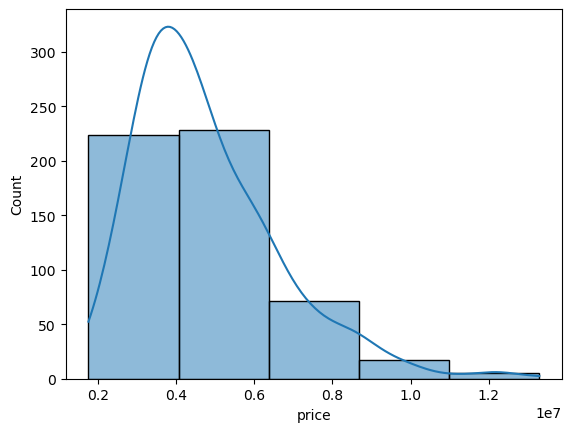

In [125]:
sns.histplot(df['price'], kde=True, bins=5)
plt.show()

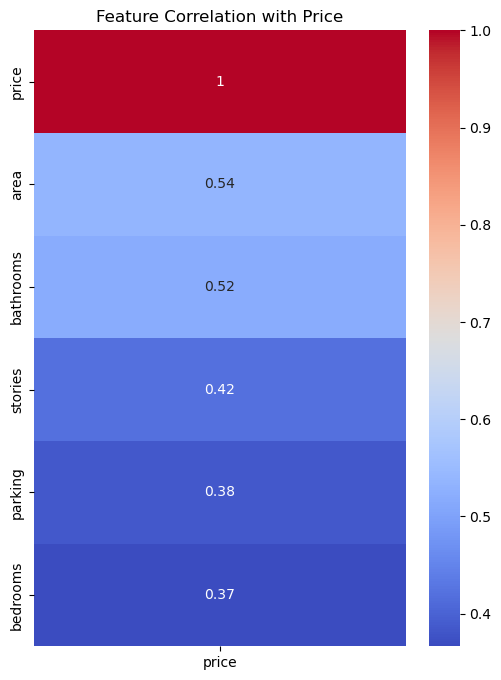

In [130]:
plt.figure(figsize=(6,8))
sns.heatmap(corr[['price']].sort_values(by='price', ascending=False),annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Price")
plt.show()

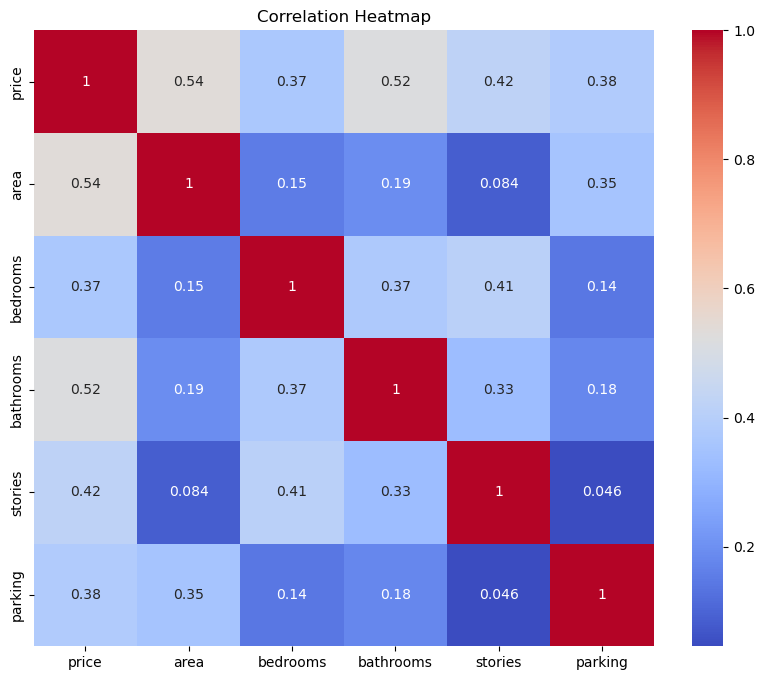

In [131]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

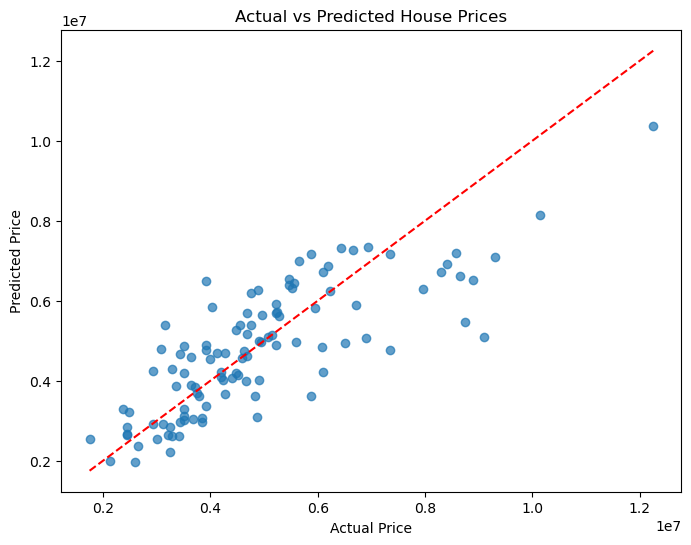

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [139]:
# Task 5 — Insights & Summary
#  Write a short paragraph (5–8 lines) inside your notebook answering:
#  Which features influence house price the most?
#  How accurate was your model (in plain terms)?
#  What surprised you in the data?
#  One recommendation for a real estate business based on your findings

In [140]:
# 1. Which features influence house price the most?
# Ans: After doing correlation analysis using heatmaps it was found out that area, bathrooms, stories, parking, and 
# air conditioning were among the most influential features affecting house prices. 
# House area showed the strongest relationship with price.

In [141]:
# 2. How accurate was your model (in plain terms)?
# Ans: The Linear Regression model performed reasonably well, achieving an R² score of about 0.63. 
# This means it was able to capture and explain around 63% of the factors affecting house prices. 
# While the predictions were not perfect, they were generally close to the actual prices,
# making the model useful for estimating property values.

In [142]:
# 3. What surprised you in the data?
# Ans: There was few things that makes this dataset unique:
# 1. No missing values
# 2. No duplicate values
# 3. Also, simple features like air conditioning and being located in a preferred area had a significant impact on house prices, 
# showing that amenities and location can be just as important as the size of the property.

In [145]:
# 4. One recommendation for a real estate business based on your findings
# Ans: Well i thing real estate buisnesses should really hight properties with better amenities like air conditioners, parking lot
# or better locations! These features often seen increasing the value of the properties and attracts more buyers and better sales,
# this reflects how people today prioritize comfort and convenience in their lifestyles, 
# and it often starts with choosing the right home.